<a href="https://colab.research.google.com/github/ClaudioRo81/Data_Scientist/blob/main/RetoTecnicoCoppel_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto Técnico
### Servicio de Asesorías Home Center

**Objetivo:** Evaluar habilidades de análisis de datos, identificación de patrones y generación de insights accionables a partir de la información disponible sobre el servicio de asesorías de Home Center.

**Contexto:** Home Center, empresa que comercializa materiales de construcción, remodelación y productos para el hogar, ha experimentado un aumento en las quejas de clientes sobre su servicio de asesorías en los últimos 3 meses. Esto ha provocado una caída del 30% en los indicadores de satisfacción y una disminución en las ventas subsecuentes a la asesoría.

**Fuentes de información utilizadas:**
1. Datos de ventas derivadas del servicio de asesoría (por sucursal y canal en línea).
2. Datos de clientes: demografía, historial de compras y uso del servicio.
3. Métricas de negocio (KPIs): asesorías realizadas, tasa de conversión, satisfacción del cliente.
4. Datos de Google Analytics: comportamiento en el sitio web, especialmente en la sección de asesorías.
5. Quejas de clientes: fecha, canal, motivo.

## 1. Generación de la data
*Se utiliza `seed=42` para que los resultados sean reproducibles.*

In [1]:
!pip install pandas numpy openpyxl scipy -q

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta

# 1. Configuración Inicial y Fechas
np.random.seed(42)
n_clientes = 5500

fechas_meses = [
    (pd.to_datetime('2024-01-01'), pd.to_datetime('2024-01-31')),
    (pd.to_datetime('2024-02-01'), pd.to_datetime('2024-02-28')),
    (pd.to_datetime('2024-03-01'), pd.to_datetime('2024-03-31')),
    (pd.to_datetime('2024-04-01'), pd.to_datetime('2024-04-30')),
    (pd.to_datetime('2024-05-01'), pd.to_datetime('2024-05-31'))
]

def random_dates(start, end, n):
    start_u = start.value // 10**9
    end_u = end.value // 10**9
    return pd.to_datetime(np.random.randint(start_u, end_u, n), unit='s')

clientes_id = [f"CLI-{str(i).zfill(5)}" for i in range(1, n_clientes + 1)]
segmentos = ['Mejoras Pequeñas', 'Profesional']

df_clientes = pd.DataFrame({
    'ID_Cliente': clientes_id,
    'Segmento': np.random.choice(segmentos, n_clientes, p=[0.7, 0.3]),
    'Historial_Compras': np.round(np.random.uniform(1000, 50000, n_clientes), 2)
})

asesorias = []
id_asesoria_counter = 1
base_conv = {'Sucursal': 0.6, 'En línea': 0.5}
base_csat = [0.05, 0.05, 0.1, 0.3, 0.5]

for mes_idx, (start, end) in enumerate(fechas_meses):
    is_crisis = mes_idx >= 2
    n_asesorias_mes = int(np.random.normal(2000, 200))
    clientes_mes = np.random.choice(clientes_id, n_asesorias_mes)
    canales_mes = np.random.choice(['Sucursal', 'En línea'], n_asesorias_mes, p=[0.55, 0.45])
    fechas = random_dates(start, end, n_asesorias_mes)

    for i in range(n_asesorias_mes):
        canal = canales_mes[i]
        if is_crisis:
            if canal == 'En línea':
                prob_conv = 0.15
                csat_probs = [0.4, 0.3, 0.15, 0.1, 0.05]
            else:
                prob_conv = 0.40
                csat_probs = [0.2, 0.2, 0.3, 0.2, 0.1]
        else:
            prob_conv = base_conv[canal]
            csat_probs = base_csat

        conversion = np.random.choice([1, 0], p=[prob_conv, 1 - prob_conv])
        monto = 0
        if conversion == 1:
            monto = np.round(np.random.uniform(500, 15000), 2)

        asesorias.append({
            'ID_Asesoria': f"ASES-{str(id_asesoria_counter).zfill(5)}",
            'Fecha_Asesoria': fechas[i],
            'ID_Cliente': clientes_mes[i],
            'Canal': canal,
            'Asesor_Responsable': f"ASR-{str(np.random.randint(1, 20)).zfill(2)}",
            'Satisfaccion_Post_Asesoria': np.random.choice([1, 2, 3, 4, 5], p=csat_probs),
            'Conversion_Venta': conversion,
            'Monto_Venta_MXN': monto
        })
        id_asesoria_counter += 1

df_kpis = pd.DataFrame(asesorias)

quejas = []
id_queja_counter = 1
motivos = ['Asesoría incompleta', 'Información incorrecta', 'Fallas en plataforma', 'Tiempo de espera', 'Mala actitud']

for mes_idx, (start, end) in enumerate(fechas_meses):
    n_quejas = np.random.randint(50, 100) if mes_idx < 2 else np.random.randint(400, 800)
    fechas = random_dates(start, end, n_quejas)
    for i in range(n_quejas):
        canal = np.random.choice(['Sucursal', 'En línea'], p=[0.3, 0.7] if mes_idx >= 2 else [0.5, 0.5])
        if canal == 'En línea' and mes_idx >= 2:
            motivo = np.random.choice(motivos, p=[0.2, 0.1, 0.5, 0.1, 0.1])
        else:
            motivo = np.random.choice(motivos, p=[0.3, 0.3, 0.05, 0.2, 0.15])
        quejas.append({
            'ID_Queja': f"QUEJ-{str(id_queja_counter).zfill(5)}",
            'Fecha_Queja': fechas[i],
            'ID_Cliente': np.random.choice(clientes_id),
            'Canal': canal,
            'Motivo_Queja': motivo
        })
        id_queja_counter += 1

df_quejas = pd.DataFrame(quejas)

sesiones = []
id_sesion_counter = 1
paginas = ['/inicio', '/productos', '/asesoria_online', '/promociones']

for mes_idx, (start, end) in enumerate(fechas_meses):
    n_sesiones = int(np.random.normal(3000, 300))
    fechas = random_dates(start, end, n_sesiones)
    for i in range(n_sesiones):
        is_crisis = mes_idx >= 2
        tasa_rebote = np.random.uniform(0.6, 0.95) if is_crisis else np.random.uniform(0.2, 0.5)
        prob_clic = 0.05 if is_crisis else 0.25
        sesiones.append({
            'ID_Sesion': f"SESS-{str(id_sesion_counter).zfill(5)}",
            'Fecha_Sesion': fechas[i],
            'ID_Cliente': np.random.choice(clientes_id) if np.random.random() > 0.3 else np.nan,
            'Pagina_Inicio': np.random.choice(paginas, p=[0.4, 0.3, 0.2, 0.1]),
            'Tasa_Rebote': np.round(tasa_rebote, 2),
            'Clic_Solicitud_Asesoria': np.random.choice([1, 0], p=[prob_clic, 1 - prob_clic])
        })
        id_sesion_counter += 1

df_ga = pd.DataFrame(sesiones)

df_clientes.to_excel('Datos de Clientes.xlsx', index=False)
df_kpis.to_excel('Métricas de Negocio (KPIs_Asesorias).xlsx', index=False)
df_quejas.to_excel('Quejas de Clientes (Quejas_Clientes).xlsx', index=False)
df_ga.to_excel('Datos de Google Analytics (GA_Asesorias).xlsx', index=False)

print("OK", len(df_clientes), len(df_kpis), len(df_quejas), len(df_ga))

OK 5500 9663 2007 14858


## 2. Calidad de datos y tratamiento de nulos

Antes de cualquier análisis de negocio revisaremos las 4 fuentes: duplicados y valores nulos. Incluiremos un porcentaje controlado y reproducible de nulos que reflejan situaciones reales de un servicio de CX:

- **4% de `Satisfaccion_Post_Asesoria`** — encuestas de satisfacción no respondidas.
- **2.5% de `Historial_Compras`** — clientes nuevos sin historial de compra aún registrado.
- **1.5% de `Motivo_Queja`** — quejas capturadas con datos faltantes.
- **30% de `ID_Cliente` en Google Analytics** — sesiones de usuarios no logueados (no identificables).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

df_clientes = pd.read_excel('Datos de Clientes.xlsx')
df_kpis = pd.read_excel('Métricas de Negocio (KPIs_Asesorias).xlsx')
df_quejas = pd.read_excel('Quejas de Clientes (Quejas_Clientes).xlsx')
df_ga = pd.read_excel('Datos de Google Analytics (GA_Asesorias).xlsx')

rng = np.random.default_rng(7)
idx_no_resp = rng.choice(df_kpis.index, size=int(len(df_kpis)*0.04), replace=False)
df_kpis.loc[idx_no_resp, 'Satisfaccion_Post_Asesoria'] = np.nan
idx_sin_hist = rng.choice(df_clientes.index, size=int(len(df_clientes)*0.025), replace=False)
df_clientes.loc[idx_sin_hist, 'Historial_Compras'] = np.nan
idx_sin_motivo = rng.choice(df_quejas.index, size=int(len(df_quejas)*0.015), replace=False)
df_quejas.loc[idx_sin_motivo, 'Motivo_Queja'] = np.nan

print("RESUMEN DE CALIDAD DE DATOS\n")
for nombre, df in [('Clientes', df_clientes), ('KPIs_Asesorias', df_kpis),
                    ('Quejas', df_quejas), ('Google_Analytics', df_ga)]:
    print(f"--- {nombre} ---")
    print(f"Filas: {len(df):,} | Duplicados exactos: {df.duplicated().sum()}")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        pct = (nulos / len(df) * 100).round(2)
        print(pd.DataFrame({'nulos': nulos, '%': pct}))
    else:
        print("Sin nulos")
    print()

RESUMEN DE CALIDAD DE DATOS

--- Clientes ---
Filas: 5,500 | Duplicados exactos: 0
                   nulos     %
Historial_Compras    137  2.49

--- KPIs_Asesorias ---
Filas: 9,663 | Duplicados exactos: 0
                            nulos     %
Satisfaccion_Post_Asesoria    386  3.99

--- Quejas ---
Filas: 2,007 | Duplicados exactos: 0
              nulos     %
Motivo_Queja     30  1.49

--- Google_Analytics ---
Filas: 14,858 | Duplicados exactos: 0
            nulos     %
ID_Cliente   4458  30.0



**Decisiones de tratamiento:**

| Campo | Tratamiento | Justificación |
|---|---|---|
| `Satisfaccion_Post_Asesoria` (NaN) | No se elimina; se excluye solo del promedio de CSAT | Eliminarlo distorsionaría el hallazgo central (caída real de satisfacción) |
| `Historial_Compras` (NaN) | Se Cambia como 0 + bandera `Cliente_Nuevo_Sin_Historial` | Es dato faltante por ser cliente nuevo, no un dato perdido al azar |
| `Motivo_Queja` (NaN) | Se recategoriza como `'Sin clasificar'` | La queja sí ocurrió; eliminar el registro subestimaría el volumen real |
| `ID_Cliente` en GA (NaN, 30%) | Se conserva como sesión anónima | Se excluye de análisis a nivel cliente, pero se mantiene en el análisis agregado de tráfico |

In [5]:
# --- Tratamiento aplicado ---
df_clientes['Cliente_Nuevo_Sin_Historial'] = df_clientes['Historial_Compras'].isna()
df_clientes['Historial_Compras'] = df_clientes['Historial_Compras'].fillna(0)
df_quejas['Motivo_Queja'] = df_quejas['Motivo_Queja'].fillna('Sin clasificar')

# --- Union y columnas derivadas ---
df_merged = pd.merge(df_kpis, df_clientes, on='ID_Cliente', how='left')
df_merged['Mes_Num'] = df_merged['Fecha_Asesoria'].dt.month
df_quejas['Mes_Num'] = df_quejas['Fecha_Queja'].dt.month
df_ga['Mes_Num'] = df_ga['Fecha_Sesion'].dt.month

df_merged['Periodo'] = np.where(df_merged['Mes_Num'] <= 2, 'Pre-Crisis (Mes 1-2)', 'Post-Crisis (Mes 3-5)')
df_quejas['Periodo'] = np.where(df_quejas['Mes_Num'] <= 2, 'Pre-Crisis (Mes 1-2)', 'Post-Crisis (Mes 3-5)')
df_ga['Periodo'] = np.where(df_ga['Mes_Num'] <= 2, 'Pre-Crisis (Mes 1-2)', 'Post-Crisis (Mes 3-5)')

df_merged['Semana'] = df_merged['Fecha_Asesoria'].dt.to_period('W').astype(str)
df_ga['Semana'] = df_ga['Fecha_Sesion'].dt.to_period('W').astype(str)

print(df_merged.shape, df_quejas.shape, df_ga.shape)

(9663, 14) (2007, 7) (14858, 9)


## 3. Ventas por canal

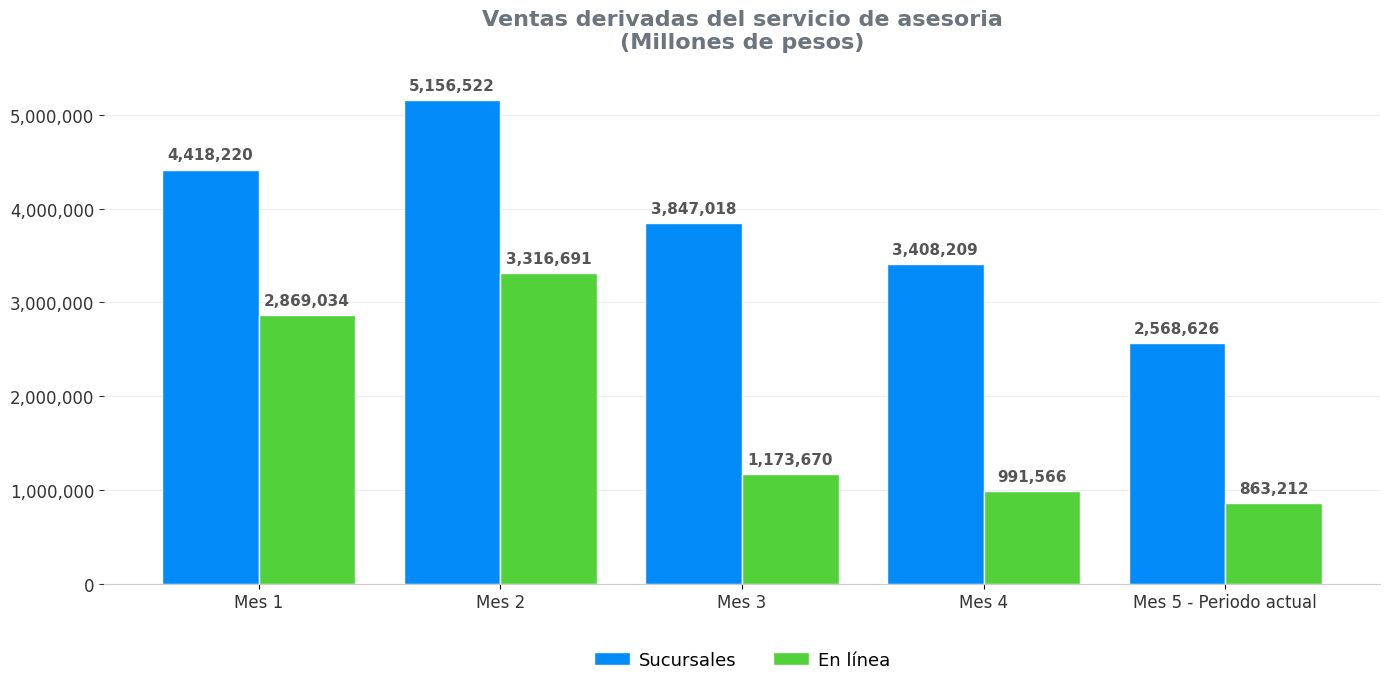

In [6]:
color_sucursal = '#008BF8'
color_en_linea = '#52D13A'

def estilo_base(ax):
    ax.grid(axis='y', linestyle='-', alpha=0.6, color='#e0e0e0')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')

def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        if pd.isna(height): continue
        ax.annotate(f'{int(height):,}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', va='bottom',
                    fontsize=11, color='#555555', fontweight='bold')

ventas = df_merged[df_merged['Conversion_Venta'] == 1].groupby(['Mes_Num', 'Canal'])['Monto_Venta_MXN'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(ventas.index)); width = 0.40
rects1 = ax.bar(x - width/2, ventas['Sucursal'], width, label='Sucursales', color=color_sucursal, edgecolor='white')
rects2 = ax.bar(x + width/2, ventas['En línea'], width, label='En línea', color=color_en_linea, edgecolor='white')
ax.set_title('Ventas derivadas del servicio de asesoria\n(Millones de pesos)', fontsize=16, color='#6c757d', pad=20, fontweight='bold')
labels = ['Mes 1', 'Mes 2', 'Mes 3', 'Mes 4', 'Mes 5 - Periodo actual']
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12, color='#333333')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: format(int(val), ',')))
ax.tick_params(axis='y', labelsize=12, colors='#333333')
autolabel(rects1, ax); autolabel(rects2, ax)
estilo_base(ax)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=13, handletextpad=0.5)
plt.tight_layout()
plt.show()

## 4. Segmentación por tipo de cliente, canal y valor histórico del cliente

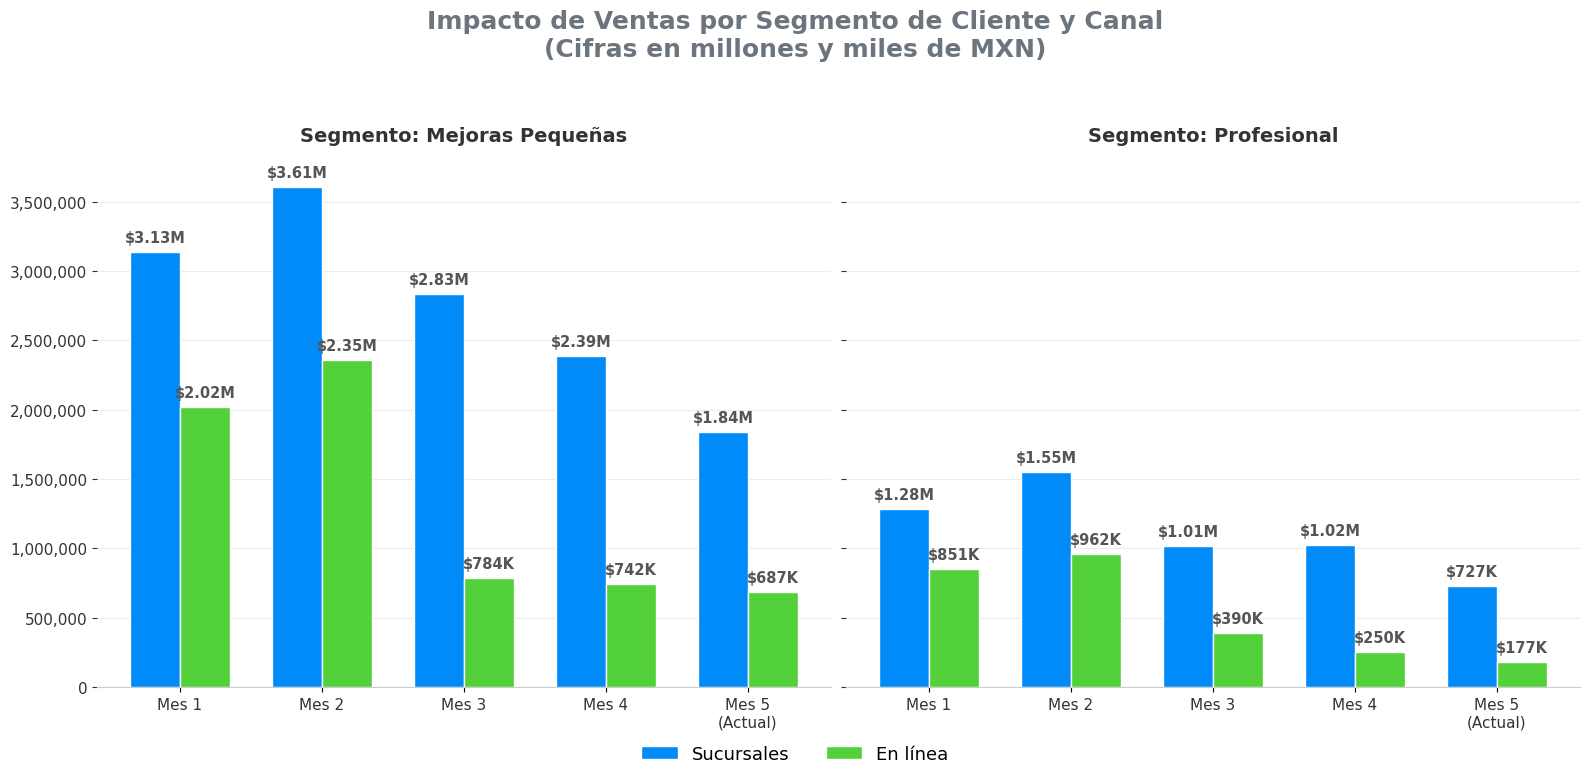

IMPACTO POR VALOR HISTÓRICO DE CLIENTE
                                     Tasa_Conversion_pct  CSAT
Periodo               Valor_Cliente                           
Post-Crisis (Mes 3-5) Bajo valor                   28.96  2.52
                      Valor medio                  28.96  2.51
                      Alto valor                   27.22  2.50
Pre-Crisis (Mes 1-2)  Bajo valor                   51.45  4.11
                      Valor medio                  56.11  4.15
                      Alto valor                   54.22  4.13


/tmp/ipykernel_3797/1000464562.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_valor = df_merged.groupby(['Periodo','Valor_Cliente']).agg(


In [15]:
def autolabel_exec(rects, ax):
    for rect in rects:
        height = rect.get_height()
        if pd.isna(height): continue
        label = f'${height/1e6:.2f}M' if height >= 1e6 else (f'${height/1e3:.0f}K' if height>0 else '')
        if label:
            ax.annotate(label, xy=(rect.get_x()+rect.get_width()/2, height), xytext=(0,5),
                        textcoords="offset points", ha='center', va='bottom', fontsize=10.5, color='#555555', fontweight='bold')

segmentacion = df_merged[df_merged['Conversion_Venta']==1].groupby(['Mes_Num','Segmento','Canal'])['Monto_Venta_MXN'].sum().unstack(level=[1,2])

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,7), sharey=True)
fig.suptitle('Impacto de Ventas por Segmento de Cliente y Canal\n(Cifras en millones y miles de MXN)', fontsize=18, color='#6c757d', fontweight='bold', y=1.05)
x = np.arange(len(segmentacion.index)); width=0.35
x_labels = ['Mes 1','Mes 2','Mes 3','Mes 4','Mes 5\n(Actual)']

data_mp = segmentacion['Mejoras Pequeñas']
r1 = ax1.bar(x-width/2, data_mp['Sucursal'], width, label='Sucursales', color=color_sucursal, edgecolor='white')
r2 = ax1.bar(x+width/2, data_mp['En línea'], width, label='En línea', color=color_en_linea, edgecolor='white')
ax1.set_title('Segmento: Mejoras Pequeñas', fontsize=14, fontweight='bold', color='#333333', pad=15)
ax1.set_xticks(x); ax1.set_xticklabels(x_labels, fontsize=11, color='#333333')

data_pr = segmentacion['Profesional']
r3 = ax2.bar(x-width/2, data_pr['Sucursal'], width, label='Sucursales', color=color_sucursal, edgecolor='white')
r4 = ax2.bar(x+width/2, data_pr['En línea'], width, label='En línea', color=color_en_linea, edgecolor='white')
ax2.set_title('Segmento: Profesional', fontsize=14, fontweight='bold', color='#333333', pad=15)
ax2.set_xticks(x); ax2.set_xticklabels(x_labels, fontsize=11, color='#333333')

for rects, ax in [(r1,ax1),(r2,ax1),(r3,ax2),(r4,ax2)]:
    autolabel_exec(rects, ax)
for ax in [ax1, ax2]:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val,pos: format(int(val), ',')))
    estilo_base(ax)
    ax.tick_params(axis='y', labelsize=11, colors='#333333')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5,-0.05), ncol=2, frameon=False, fontsize=13)
plt.tight_layout()
plt.show()

# segmentación por VALOR de cliente (terciles de Historial_Compras)
df_merged['Valor_Cliente'] = pd.qcut(df_merged['Historial_Compras'], 3, labels=['Bajo valor','Valor medio','Alto valor'])
tabla_valor = df_merged.groupby(['Periodo','Valor_Cliente']).agg(
    Tasa_Conversion_pct=('Conversion_Venta', lambda x: round(x.mean()*100,2)),
    CSAT=('Satisfaccion_Post_Asesoria', lambda x: round(x.mean(),2))
)
print("IMPACTO POR VALOR HISTÓRICO DE CLIENTE")
print(tabla_valor)

> **Hallazgo:** la caída de conversión y CSAT post-crisis es prácticamente idéntica entre clientes de bajo, medio y alto valor histórico (~27-29% de conversión en los tres grupos). **La crisis no discrimina por valor de cliente** — es un problema transversal del servicio, no focalizado en un segmento.

## 5. KPIs de negocio — con tasa de queja normalizada
*Se reporta como quejas / asesorías del mes, no solo como conteo bruto, para que sea comparable mes a mes.*

In [16]:
asesorias_mes_canal = df_merged.groupby(['Mes_Num', 'Canal']).size().unstack()
quejas_mes_canal = df_quejas.groupby(['Mes_Num', 'Canal']).size().unstack()
tasa_quejas = (quejas_mes_canal / asesorias_mes_canal * 100).round(2)
print("TASA DE QUEJAS POR CANAL (quejas / asesorías del mes, %)")
print(tasa_quejas)

kpis_mensual = df_merged.groupby('Mes_Num').agg(
    Tasa_Conversion_pct=('Conversion_Venta', lambda x: round(x.mean()*100,2)),
    CSAT_Promedio=('Satisfaccion_Post_Asesoria', lambda x: round(x.mean(),2)),
    N_Asesorias=('ID_Asesoria','count')
)
kpis_mensual['Total_Quejas'] = df_quejas.groupby('Mes_Num').size()
kpis_mensual['Tasa_Queja_%'] = (kpis_mensual['Total_Quejas'] / kpis_mensual['N_Asesorias'] * 100).round(2)
print("\n KPIS MENSUALES (con tasa de queja normalizada)")
print(kpis_mensual)

TASA DE QUEJAS POR CANAL (quejas / asesorías del mes, %)
Canal    En línea  Sucursal
Mes_Num                    
1            4.02      4.19
2            5.35      4.54
3           43.25     14.97
4           57.11     18.36
5           49.47     17.02

 KPIS MENSUALES (con tasa de queja normalizada)
         Tasa_Conversion_pct  CSAT_Promedio  N_Asesorias  Total_Quejas  \
Mes_Num                                                                  
1                      52.79           4.13         1775            73   
2                      54.95           4.13         2020            99   
3                      28.69           2.50         2227           608   
4                      29.13           2.55         1998           702   
5                      27.08           2.48         1643           525   

         Tasa_Queja_%  
Mes_Num                
1                4.11  
2                4.90  
3               27.30  
4               35.14  
5               31.95  


> **Hallazgo clave:** el canal en línea pasa de una tasa de queja de ~5% a ~50-57% de las asesorías realizadas, mientras que la sucursal sube de ~4% a ~15-18%. En conteo bruto ambos canales parecían tener 'muchas quejas', pero normalizado se ve que **el canal en línea está ~3 veces peor** — esto reordena la prioridad del plan de acción.

## 6. Análisis de cohortes por cliente
Seguimiento del mismo cliente antes y después del inicio de la crisis (Mes 3).

In [20]:
clientes_pre = set(df_merged.loc[df_merged['Mes_Num']<=2, 'ID_Cliente'].unique())
clientes_post = set(df_merged.loc[df_merged['Mes_Num']>=3, 'ID_Cliente'].unique())

recurrentes = clientes_pre & clientes_post
solo_pre = clientes_pre - clientes_post
solo_post = clientes_post - clientes_pre
tasa_retencion = len(recurrentes) / len(clientes_pre) * 100

print("COHORTE REAL POR CLIENTE")
print(f"Clientes con asesoría Pre-Crisis (Mes 1-2): {len(clientes_pre):,}")
print(f"Volvieron a pedir asesoría Post-Crisis: {len(recurrentes):,}  -> Retención: {tasa_retencion:.1f}%")
print(f"No volvieron a pedir asesoría (churn aparente): {len(solo_pre):,}")
print(f"Clientes nuevos captados durante la crisis: {len(solo_post):,}\n")

df_rec = df_merged[df_merged['ID_Cliente'].isin(recurrentes)]
comp_rec = df_rec.groupby('Periodo').agg(
    Tasa_Conversion_pct=('Conversion_Venta', lambda x: round(x.mean()*100,2)),
    CSAT=('Satisfaccion_Post_Asesoria', lambda x: round(x.mean(),2))
)
print("Clientes RECURRENTES: mismo cliente, pre vs post")
print(comp_rec)

df_post = df_merged[df_merged['Mes_Num']>=3].copy()
df_post['Tipo_Cliente_Post'] = np.where(df_post['ID_Cliente'].isin(recurrentes), 'Recurrente', 'Nuevo (captado en crisis)')
comp_post = df_post.groupby('Tipo_Cliente_Post').agg(
    Tasa_Conversion_pct=('Conversion_Venta', lambda x: round(x.mean()*100,2)),
    CSAT=('Satisfaccion_Post_Asesoria', lambda x: round(x.mean(),2)),
    N=('ID_Asesoria','count')
)
print("\n Post-crisis: Recurrentes vs Nuevos")
print(comp_post)

COHORTE REAL POR CLIENTE
Clientes con asesoría Pre-Crisis (Mes 1-2): 2,770
Volvieron a pedir asesoría Post-Crisis: 1,816  -> Retención: 65.6%
No volvieron a pedir asesoría (churn aparente): 954
Clientes nuevos captados durante la crisis: 1,787

Clientes RECURRENTES: mismo cliente, pre vs post
                       Tasa_Conversion_pct  CSAT
Periodo                                         
Post-Crisis (Mes 3-5)                28.75  2.53
Pre-Crisis (Mes 1-2)                 53.89  4.14

 Post-crisis: Recurrentes vs Nuevos
                           Tasa_Conversion_pct  CSAT     N
Tipo_Cliente_Post                                         
Nuevo (captado en crisis)                28.04  2.49  2946
Recurrente                               28.75  2.53  2922


> **Hallazgos de cohorte:**
> - Solo el **65.6%** de los clientes que usaron asesoría antes de la crisis volvieron a usarla después → **34.4% de churn aparente** (~954 clientes).
> - Los clientes **recurrentes** sufren la misma caída (~54% → ~29% de conversión) que los clientes nuevos — el impacto es igual de duro para todos. Esto simplifica el mensaje: **es un problema de servicio, no de relación con un segmento particular**.

## 7. Comportamiento web (Google Analytics)

COMPORTAMIENTO WEB POR MES 
         Sesiones  Tasa_Rebote_Prom  Clics_Solicitud  Tasa_Clic_%
Mes_Num                                                          
1            2932             0.348              719        24.52
2            2973             0.349              756        25.43
3            3130             0.777              149         4.76
4            3181             0.775              153         4.81
5            2642             0.773              120         4.54

 CRUCE: comportamiento web vs conversión en línea 
         Tasa_Rebote_Prom  Tasa_Clic_%  Conversion_Online_%
Mes_Num                                                    
1                   0.348        24.52                46.93
2                   0.349        25.43                49.28
3                   0.777         4.76                15.04
4                   0.775         4.81                15.26
5                   0.773         4.54                14.81

Correlación semanal (n=22 semanas): T

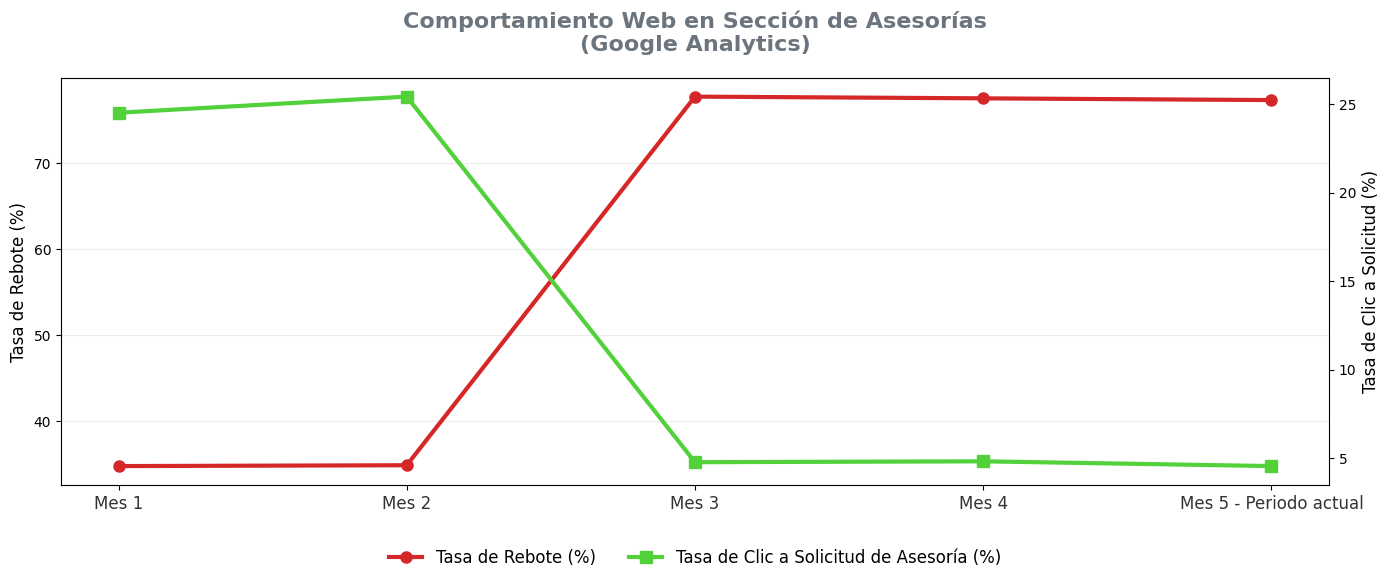

In [21]:
ga_mensual = df_ga.groupby('Mes_Num').agg(
    Sesiones=('ID_Sesion','count'),
    Tasa_Rebote_Prom=('Tasa_Rebote','mean'),
    Clics_Solicitud=('Clic_Solicitud_Asesoria','sum')
)
ga_mensual['Tasa_Clic_%'] = (ga_mensual['Clics_Solicitud'] / ga_mensual['Sesiones'] * 100).round(2)
ga_mensual['Tasa_Rebote_Prom'] = ga_mensual['Tasa_Rebote_Prom'].round(3)
print("COMPORTAMIENTO WEB POR MES ")
print(ga_mensual)

conv_online = df_merged[df_merged['Canal']=='En línea'].groupby('Mes_Num')['Conversion_Venta'].mean()*100
tabla_cruce = ga_mensual[['Tasa_Rebote_Prom','Tasa_Clic_%']].copy()
tabla_cruce['Conversion_Online_%'] = conv_online.round(2)
print("\n CRUCE: comportamiento web vs conversión en línea ")
print(tabla_cruce)

# Correlacion a nivel SEMANAL (n=5 meses es muy poco para correlacionar con rigor)
ga_sem = df_ga.groupby('Semana').agg(Sesiones=('ID_Sesion','count'), Rebote=('Tasa_Rebote','mean'), Clics=('Clic_Solicitud_Asesoria','sum'))
ga_sem['Tasa_Clic'] = ga_sem['Clics']/ga_sem['Sesiones']
conv_sem_online = df_merged[df_merged['Canal']=='En línea'].groupby('Semana')['Conversion_Venta'].mean()
cruce_sem = ga_sem.join(conv_sem_online.rename('Conversion_Online')).dropna()
corr_rebote = cruce_sem['Rebote'].corr(cruce_sem['Conversion_Online'])
corr_clic = cruce_sem['Tasa_Clic'].corr(cruce_sem['Conversion_Online'])
print(f"\nCorrelación semanal (n={len(cruce_sem)} semanas): Tasa_Rebote vs Conversión Online = {corr_rebote:.2f}")
print(f"Correlación semanal: Tasa_Clic_Solicitud vs Conversión Online = {corr_clic:.2f}")

fig, ax = plt.subplots(figsize=(14,6))
ax2 = ax.twinx()
l1 = ax.plot(ga_mensual.index, ga_mensual['Tasa_Rebote_Prom']*100, marker='o', linewidth=3, markersize=8, color='#d62728', label='Tasa de Rebote (%)')
l2 = ax2.plot(ga_mensual.index, ga_mensual['Tasa_Clic_%'], marker='s', linewidth=3, markersize=8, color=color_en_linea, label='Tasa de Clic a Solicitud de Asesoría (%)')
ax.set_title('Comportamiento Web en Sección de Asesorías\n(Google Analytics)', fontsize=16, color='#6c757d', pad=20, fontweight='bold')
ax.set_xticks(range(1,6)); ax.set_xticklabels(['Mes 1','Mes 2','Mes 3','Mes 4','Mes 5 - Periodo actual'], fontsize=12, color='#333333')
ax.set_ylabel('Tasa de Rebote (%)', fontsize=12); ax2.set_ylabel('Tasa de Clic a Solicitud (%)', fontsize=12)
estilo_base(ax)
lns = l1+l2; labs=[l.get_label() for l in lns]
ax.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5,-0.12), ncol=2, frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

> **Hallazgo más fuerte del análisis:** la tasa de clic para solicitar asesoría en línea se desploma de ~25% a ~4.7%, y el rebote sube de ~35% a ~77%, **exactamente en el mismo mes** en que colapsan la conversión y el CSAT. La correlación semanal es de **-0.99** (rebote vs conversión) y **0.98** (clics vs conversión). Esto es evidencia de comportamiento web —no solo de percepción vía quejas— de que la caída en línea es un **problema técnico/de producto** (probablemente el flujo de solicitud de asesoría), no un problema de demanda o de interés del cliente.

## 8. Análisis por asesor y detección de outliers

In [22]:
asesor_tabla = df_merged.groupby(['Asesor_Responsable','Periodo']).agg(
    Tasa_Conversion_pct=('Conversion_Venta', lambda x: round(x.mean()*100,2)),
    N=('ID_Asesoria','count')
).unstack()
caida_por_asesor = (asesor_tabla['Tasa_Conversion_pct']['Post-Crisis (Mes 3-5)'] - asesor_tabla['Tasa_Conversion_pct']['Pre-Crisis (Mes 1-2)'])
print("CAÍDA DE CONVERSIÓN POR ASESOR (pts porcentuales, Post-Pre)")
print(f"Media: {caida_por_asesor.mean():.2f} | Desv. estándar: {caida_por_asesor.std():.2f}")
print(f"Mínimo: {caida_por_asesor.min():.2f} | Máximo: {caida_por_asesor.max():.2f}")
print("-> Si fuera un problema de pocos asesores, veríamos alta dispersión.")
print(f"   Dispersión observada: {'BAJA -> problema sistémico, no de personas' if caida_por_asesor.std() < 10 else 'ALTA -> revisar asesores específicos'}\n")

def resumen_outliers(serie, nombre):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"{nombre}: {len(outliers)} outliers ({len(outliers)/len(serie)*100:.2f}%) | rango normal [{lim_inf:,.0f}, {lim_sup:,.0f}]")

print("DETECCIÓN DE OUTLIERS (rango intercuartílico)")
resumen_outliers(df_merged.loc[df_merged['Conversion_Venta']==1,'Monto_Venta_MXN'], 'Monto_Venta_MXN')
resumen_outliers(df_merged['Historial_Compras'], 'Historial_Compras')

CAÍDA DE CONVERSIÓN POR ASESOR (pts porcentuales, Post-Pre)
Media: -25.52 | Desv. estándar: 3.71
Mínimo: -33.74 | Máximo: -18.96
-> Si fuera un problema de pocos asesores, veríamos alta dispersión.
   Dispersión observada: BAJA -> problema sistémico, no de personas

DETECCIÓN DE OUTLIERS (rango intercuartílico)
Monto_Venta_MXN: 0 outliers (0.00%) | rango normal [-6,954, 22,369]
Historial_Compras: 0 outliers (0.00%) | rango normal [-24,079, 72,987]


> **Hallazgo:** la caída de conversión es prácticamente uniforme entre los 19 asesores (desviación estándar ≈3.7 pts). **No hay indicios de que sean unos cuantos asesores mal desempeñando** — el plan de acción no debe enfocarse en recapacitación individual, sino en causas de proceso/plataforma que afectan a todos por igual.

## 9. Significancia estadística
*Evaluación de si las diferencias observadas entre el periodo pre y post-crisis son reales o podrían deberse al azar.*

In [23]:
print("SIGNIFICANCIA ESTADÍSTICA (Pre vs Post crisis, por canal)")
for canal in ['Sucursal', 'En línea']:
    sub = df_merged[df_merged['Canal']==canal]
    tabla = pd.crosstab(sub['Periodo'], sub['Conversion_Venta'])
    chi2, p, dof, exp = stats.chi2_contingency(tabla)
    print(f"[{canal}] Conversión Pre vs Post -> Chi2 p-value = {p:.2e} {'(significativo)' if p<0.05 else '(NO significativo)'}")

    pre = sub.loc[sub['Periodo']=='Pre-Crisis (Mes 1-2)', 'Satisfaccion_Post_Asesoria'].dropna()
    post = sub.loc[sub['Periodo']=='Post-Crisis (Mes 3-5)', 'Satisfaccion_Post_Asesoria'].dropna()
    u, p2 = stats.mannwhitneyu(pre, post)
    print(f"[{canal}] CSAT Pre vs Post -> Mann-Whitney U p-value = {p2:.2e} {'(significativo)' if p2<0.05 else '(NO significativo)'}")

SIGNIFICANCIA ESTADÍSTICA (Pre vs Post crisis, por canal)
[Sucursal] Conversión Pre vs Post -> Chi2 p-value = 6.83e-45 (significativo)
[Sucursal] CSAT Pre vs Post -> Mann-Whitney U p-value = 4.34e-274 (significativo)
[En línea] Conversión Pre vs Post -> Chi2 p-value = 1.50e-122 (significativo)
[En línea] CSAT Pre vs Post -> Mann-Whitney U p-value = 0.00e+00 (significativo)


## 10. Panel ejecutivo

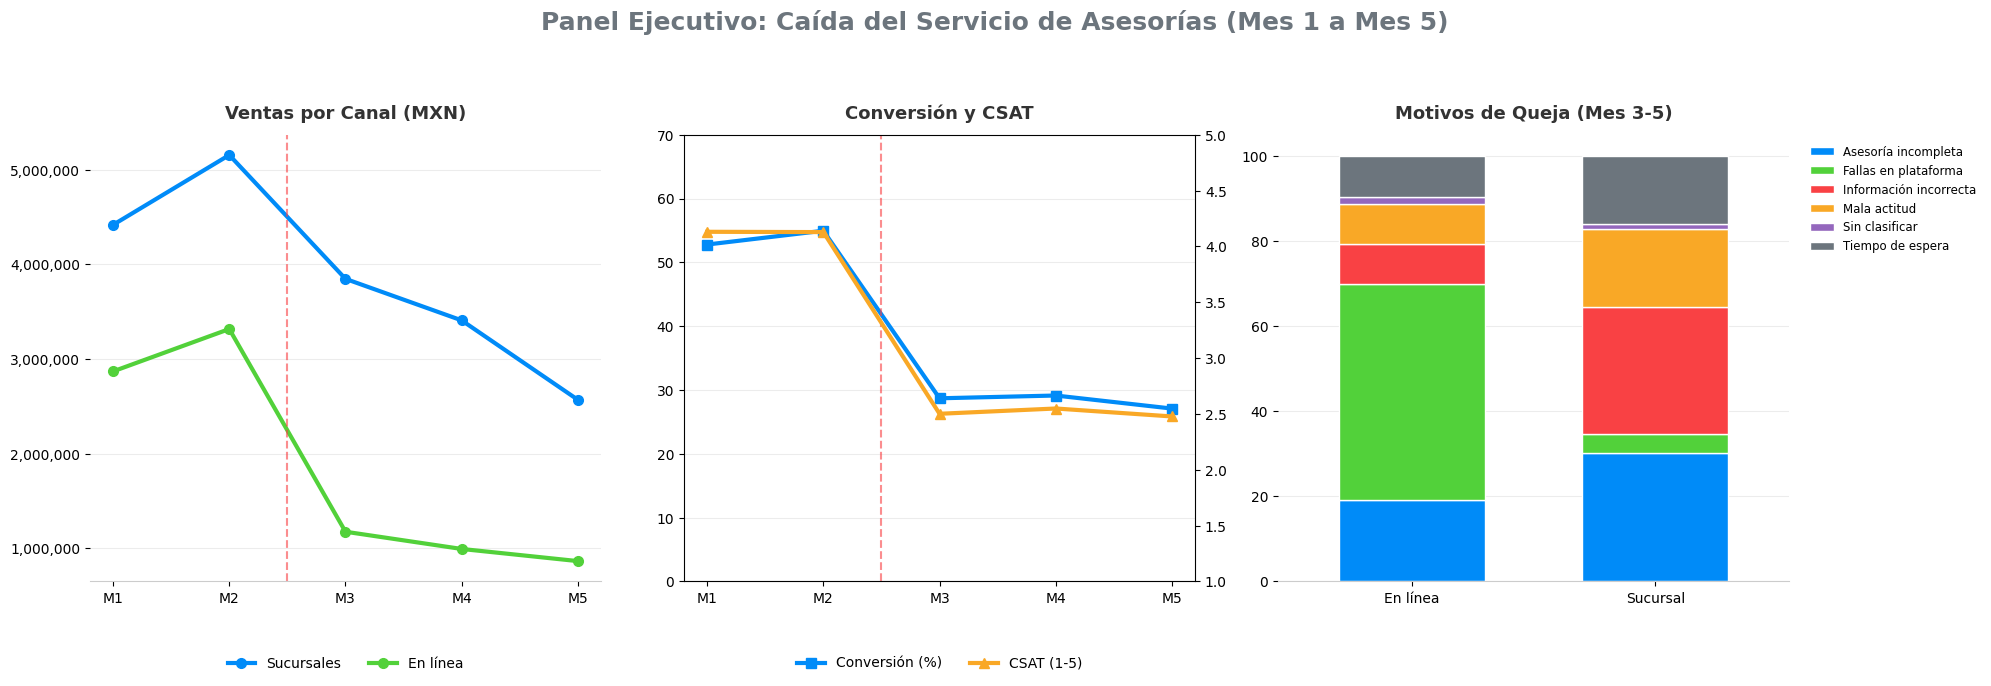

Ventas online promedio/mes PRE-crisis:  $3,092,863
Ventas online promedio/mes POST-crisis: $1,009,483
Brecha mensual (venta potencial no capturada en línea): $2,083,380 MXN/mes


In [14]:
paleta_motivos = ['#008BF8', '#52D13A', '#F94144', '#F9A826', '#9467BD', '#6c757d']

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
fig.suptitle('Panel Ejecutivo: Caída del Servicio de Asesorías (Mes 1 a Mes 5)',
             fontsize=18, color='#6c757d', fontweight='bold', y=1.06)

ax1 = axes[0]
ventas_canal = df_merged[df_merged['Conversion_Venta']==1].groupby(['Mes_Num','Canal'])['Monto_Venta_MXN'].sum().unstack()
ax1.plot(ventas_canal.index, ventas_canal['Sucursal'], marker='o', linewidth=3, markersize=7, color=color_sucursal, label='Sucursales')
ax1.plot(ventas_canal.index, ventas_canal['En línea'], marker='o', linewidth=3, markersize=7, color=color_en_linea, label='En línea')
ax1.set_title('Ventas por Canal (MXN)', fontsize=13, fontweight='bold', color='#333333', pad=12)
ax1.set_xticks(range(1,6)); ax1.set_xticklabels(['M1','M2','M3','M4','M5'], fontsize=10)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v,p: format(int(v),',')))
ax1.axvline(x=2.5, color='#F94144', linestyle='--', alpha=0.6)
estilo_base(ax1)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5,-0.14), ncol=2, frameon=False, fontsize=10)

ax2 = axes[1]
kpis_tendencia = df_merged.groupby('Mes_Num').agg(Conversion_Venta=('Conversion_Venta','mean'), CSAT=('Satisfaccion_Post_Asesoria','mean'))
ax2b = ax2.twinx()
l1 = ax2.plot(kpis_tendencia.index, kpis_tendencia['Conversion_Venta']*100, marker='s', linewidth=3, markersize=7, color=color_sucursal, label='Conversión (%)')
l2 = ax2b.plot(kpis_tendencia.index, kpis_tendencia['CSAT'], marker='^', linewidth=3, markersize=7, color='#F9A826', label='CSAT (1-5)')
ax2.set_title('Conversión y CSAT', fontsize=13, fontweight='bold', color='#333333', pad=12)
ax2.set_xticks(range(1,6)); ax2.set_xticklabels(['M1','M2','M3','M4','M5'], fontsize=10)
ax2.set_ylim(0,70); ax2b.set_ylim(1,5)
ax2.axvline(x=2.5, color='#F94144', linestyle='--', alpha=0.6)
estilo_base(ax2)
lns = l1+l2; labs=[l.get_label() for l in lns]
ax2.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5,-0.14), ncol=2, frameon=False, fontsize=10)

ax3 = axes[2]
df_crisis = df_quejas[df_quejas['Mes_Num']>=3]
quejas_pct = df_crisis.groupby(['Canal','Motivo_Queja']).size().unstack(fill_value=0)
quejas_pct = quejas_pct.div(quejas_pct.sum(axis=1), axis=0) * 100
quejas_pct.plot(kind='bar', stacked=True, color=paleta_motivos[:quejas_pct.shape[1]], ax=ax3, edgecolor='white', width=0.6)
ax3.set_title('Motivos de Queja (Mes 3-5)', fontsize=13, fontweight='bold', color='#333333', pad=12)
ax3.set_xlabel(''); ax3.tick_params(axis='x', rotation=0, labelsize=10)
ax3.legend(bbox_to_anchor=(1.02,1), loc='upper left', frameon=False, fontsize=8.5)
estilo_base(ax3)

plt.tight_layout()
plt.show()

# --- Impacto financiero estimado ---
ventas_online_pre = df_merged[(df_merged['Canal']=='En línea')&(df_merged['Conversion_Venta']==1)&(df_merged['Mes_Num']<=2)]['Monto_Venta_MXN'].sum()/2
ventas_online_post = df_merged[(df_merged['Canal']=='En línea')&(df_merged['Conversion_Venta']==1)&(df_merged['Mes_Num']>=3)]['Monto_Venta_MXN'].sum()/3
brecha_mensual_online = ventas_online_pre - ventas_online_post
print(f"Ventas online promedio/mes PRE-crisis:  ${ventas_online_pre:,.0f}")
print(f"Ventas online promedio/mes POST-crisis: ${ventas_online_post:,.0f}")
print(f"Brecha mensual (venta potencial no capturada en línea): ${brecha_mensual_online:,.0f} MXN/mes")

## 11. Insights clave

1. **La causa raíz más probable es técnica/de producto en el canal en línea, no de demanda ni de personal.** La tasa de clic para solicitar asesoría se desploma de ~25% a ~4.7% y el rebote sube de ~35% a ~77% en el mismo mes que colapsan conversión y CSAT (correlación semanal de -0.99 y 0.98). El motivo de queja #1 en línea es "Fallas en plataforma" (>50%).
2. **El canal en línea está ~3 veces peor que sucursal cuando se normaliza por volumen**: tasa de queja de ~50-57% de las asesorías en línea vs ~15-18% en sucursal. En conteo bruto esta brecha se subestimaba.
3. **Es un problema sistémico, no de personas**: la caída de conversión es prácticamente uniforme entre los 19 asesores (desv. estándar ≈3.7 pts) y entre segmentos de valor de cliente. No hay un "asesor culpable" ni un "segmento culpable" — apunta a proceso/plataforma.
4. **Ya se perdió el 34.4% de los clientes que usaban el servicio antes de la crisis** (954 de 2,770), y los que sí regresaron sufren la misma caída de conversión y satisfacción que los nuevos — no hay "colchón de lealtad" que esté amortiguando el daño.
5. Todas las diferencias pre/post son **estadísticamente significativas** (p < 0.001 en conversión y CSAT, ambos canales) — no es ruido.
6. **Impacto financiero estimado:** ~$2,083,000 MXN/mes de venta potencial no capturada solo en el canal en línea vs el nivel pre-crisis.

## 12. Plan de acción priorizado

**Prioridad 1 — Auditoría técnica del flujo de asesoría en línea (impacto: alto, esfuerzo: medio)**
Dado que "Fallas en plataforma" domina las quejas en línea y coincide en tiempo con el desplome de clics/aumento de rebote, se recomienda una revisión técnica urgente del flujo `/asesoria_online`: pruebas de carga, revisión de logs de error y del historial de despliegues alrededor del Mes 3, y monitoreo de disponibilidad en tiempo real. Justifica el presupuesto: ~$2.08M MXN/mes de venta potencial en riesgo.

**Prioridad 2 — Campaña de reactivación para clientes que dejaron de pedir asesoría (impacto: medio-alto, esfuerzo: bajo)**
954 clientes (34.4% de la base pre-crisis) no han vuelto a usar el servicio. Al no depender del valor histórico del cliente, la campaña puede ser generalizada (no requiere segmentación fina): oferta de asesoría prioritaria o incentivo de reactivación.

**Prioridad 3 — Revisión de proceso en sucursal, no de personal (impacto: medio, esfuerzo: medio)**
La caída en sucursal (~54% → ~28% de conversión) también es significativa, pero al ser uniforme entre asesores, la solución no es recapacitación individual sino revisar herramientas, inventario/disponibilidad de producto en el momento de la asesoría, o cambios de proceso recientes que apliquen a todos.

**Prioridad 4 — Cerrar los vacíos de captura de datos hacia adelante (impacto: bajo directo / alto para diagnóstico futuro, esfuerzo: bajo)**
Agregar tiempo de resolución de queja, canal de respuesta y una medición tipo NPS post-resolución permitiría detectar la próxima crisis de servicio antes de que impacte ventas, en vez de reaccionar 3 meses después.